# Helmholtz Equation 1D with PINNs with PML Boundary Conditions

This code is based on the following tutorial: 

Manuela Bastidas Olivares, Nicolás Guarín-Zapata. (2024). nicoguaro/pinns_mapi-3: Tutorial de PINNs MAPI-3 v1.0 (v1.0). Zenodo. https://doi.org/10.5281/zenodo.11974585

In [116]:
# Esto permite tener gráficos interactivos en
# el caso de correrse en Google Colab
if 'google.colab' in str(get_ipython()):
    %pip install ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

In [117]:
%matplotlib inline

In [118]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.autograd import grad

In [119]:
if 'google.colab' in str(get_ipython()):
    style = "https://raw.githubusercontent.com/nicoguaro/pinns_mapi-3/main/notebooks/clean.mplstyle"
else:
    style = "../notebooks/clean.mplstyle"
plt.style.use(style)

In [120]:
class Model(torch.nn.Module):
    def __init__(self, neurons, n_layers, activation=torch.tanh):
        super(Model, self).__init__()
        self.activation = activation
        self.layers = torch.nn.ModuleList()
        self.layers.append(torch.nn.Linear(1, neurons))
        for _ in range(n_layers-2):
            self.layers.append(torch.nn.Linear(neurons, neurons))
        self.layers.append(torch.nn.Linear(neurons, 2))

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = self.activation(layer(x))
        x = self.layers[-1](x)
        return x

In [121]:
# def f_rhs(x, k=1, a=2):
#     return (k**2 - a**2 * torch.pi**2) * torch.sin(a * torch.pi * x)

def f_rhs(x, phase=torch.pi/6):
    return 1e3*torch.exp(-((x - 0)**2) / (2 * 0.01**2))*np.exp(1j*phase)

def e_x(x, freq, lpml=0.5):
    sigma_x = torch.where(
        torch.abs(x) >= 1 - lpml, 
        2*torch.pi*4*freq*((torch.abs(x)-(1 - lpml))/lpml)**2,
        0
    )
    
    return 1 - 1j * sigma_x / (2*torch.pi*freq)


def residual(u, x, f, e_x, freq=5, vel=1.5):
    u_real = u[:,0:1]
    u_imag = u[:,1:2]
    u_comp = torch.complex(u_real, u_imag)
    
    # Compute gradients for real and imaginary parts separately
    du_real = grad(u_real, x, grad_outputs=torch.ones_like(u_real), create_graph=True)[0]
    du_imag = grad(u_imag, x, grad_outputs=torch.ones_like(u_imag), create_graph=True)[0]
    
    # Second derivatives
    ddu_real = grad(du_real, x, grad_outputs=torch.ones_like(du_real), create_graph=True)[0]
    ddu_imag = grad(du_imag, x, grad_outputs=torch.ones_like(du_imag), create_graph=True)[0]
    ddu_comp = torch.complex(ddu_real, ddu_imag)
    
    # Return the residual
    return ddu_comp/((2*torch.pi*freq/vel)**2) +  e_x(x, freq) * u_comp - f(x)/((2*torch.pi*freq/vel)**2)
    # return ddu_comp/((2*torch.pi*freq/vel)**2) +  u_comp - f(x)/((2*torch.pi*freq/vel)**2)

    # du = grad(u_comp, x, grad_outputs=torch.ones_like(u_comp, dtype=torch.complex64), create_graph=True)[0]
    # ddu = grad(du/e_x(x, freq), x, grad_outputs=torch.ones_like(du, dtype=torch.complex64), create_graph=True)[0]
    # return ddu + e_x(x, freq)*(2*torch.pi*freq/vel)**2 * u - f(x)


def loss_fn(u_model, x, f, e_x):
    u = u_model(x)
    res = residual(u, x, f, e_x)
    res_MSE = torch.mean(torch.abs(res)**2)
    bc = u_model(torch.tensor([-1.]))**2 + u_model(torch.tensor([1.]))**2
    return res_MSE + bc[0]
    # return res_MSE


def train(model, optimizer, scheduler, loss_fn, f, e_x, n_pts, iterations):
    losses = []
    for iteration in range(iterations):  
        optimizer.zero_grad()
        x = torch.FloatTensor(n_pts,1).uniform_(-1., 1.).requires_grad_(True)
        loss = loss_fn(model, x, f, e_x)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        
        if iteration % 100 == 0:
            print(f'Iteration {iteration}, Loss {loss.item()}')
            print(f"Epoch {iteration}, LR: {current_lr:.8f}, Loss: {loss.item():.4f}")
    return losses

def train_lbfgs(model, optimizer_lbfgs, loss_fn, f, iterations, e_x, x):

    def closure():
        optimizer_lbfgs.zero_grad()
        loss = loss_fn(model, x, f, e_x)
        loss.backward()
        return loss
    
    losses = []
    for iteration in range(iterations): 
        loss = optimizer_lbfgs.step(closure)
        losses.append(loss.item())
        if iteration % 100 == 0:
            print(f"[L-BFGS] Epoch {iteration}, Loss: {loss.item():.4f}")
        
    return losses

In [122]:
nn = 40
nl = 5
model = Model(neurons=nn, n_layers=nl)
for layer in model.layers:
    torch.nn.init.xavier_uniform_(layer.weight, gain=torch.nn.init.calculate_gain('tanh'))  # Xavier/Glorot initialization
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Número de parámetros
sum(p.numel() for p in model.parameters() if p.requires_grad)

5082

In [123]:
n_pts = 1000
iterations = 2500

In [124]:
start_lr = 1e-3
end_lr = 1e-4
gamma = (end_lr / start_lr) ** (1 / iterations)  # exponential decay factor

# Exponential scheduler
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

In [125]:
losses = train(model, optimizer, scheduler, loss_fn, f_rhs, e_x, n_pts, iterations)

Iteration 0, Loss 48.4801025390625
Epoch 0, LR: 0.00099908, Loss: 48.4801
Iteration 100, Loss 0.0578281544148922
Epoch 100, LR: 0.00091117, Loss: 0.0578
Iteration 200, Loss 0.040774617344141006
Epoch 200, LR: 0.00083100, Loss: 0.0408
Iteration 300, Loss 0.0537952296435833
Epoch 300, LR: 0.00075788, Loss: 0.0538
Iteration 400, Loss 0.027118822559714317
Epoch 400, LR: 0.00069119, Loss: 0.0271
Iteration 500, Loss 0.06696907430887222
Epoch 500, LR: 0.00063038, Loss: 0.0670
Iteration 600, Loss 0.026717428117990494
Epoch 600, LR: 0.00057491, Loss: 0.0267
Iteration 700, Loss 0.05832137539982796
Epoch 700, LR: 0.00052432, Loss: 0.0583
Iteration 800, Loss 0.05938809737563133
Epoch 800, LR: 0.00047819, Loss: 0.0594
Iteration 900, Loss 0.03521667793393135
Epoch 900, LR: 0.00043611, Loss: 0.0352
Iteration 1000, Loss 0.05078040435910225
Epoch 1000, LR: 0.00039774, Loss: 0.0508
Iteration 1100, Loss 0.03252140432596207
Epoch 1100, LR: 0.00036274, Loss: 0.0325
Iteration 1200, Loss 0.03741903603076935


In [126]:
n_pts = 1000
optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1, max_iter=20)
xlist_torch = torch.FloatTensor(n_pts,1).uniform_(-1., 1.).requires_grad_(True)

In [127]:
iterations = 300
losses = train_lbfgs(model, optimizer_lbfgs, loss_fn, f_rhs, iterations, e_x, xlist_torch)

[L-BFGS] Epoch 0, Loss: 0.0397
[L-BFGS] Epoch 100, Loss: 0.0016
[L-BFGS] Epoch 200, Loss: 0.0000


In [128]:
xlist = np.linspace(-1., 1., n_pts)
xlist_torch = torch.tensor(xlist, dtype=torch.float32, requires_grad=True).view(-1, 1)

In [129]:
u_ap = model(xlist_torch)

Text(0, 0.5, 'u(x)')

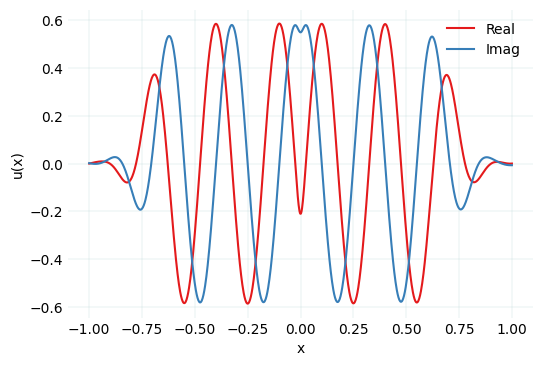

In [130]:
fig, ax = plt.subplots()
plt.plot(xlist, u_ap.detach().numpy())
plt.legend(['Real', 'Imag'])
plt.xlabel("x")
plt.ylabel("u(x)")

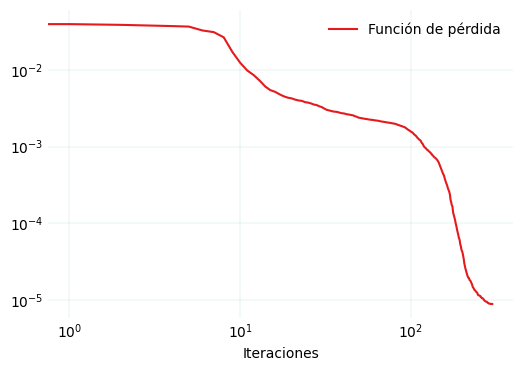

In [131]:
fig, ax = plt.subplots()
plt.loglog(losses)
plt.xlabel("Iteraciones")
plt.legend(['Función de pérdida'])

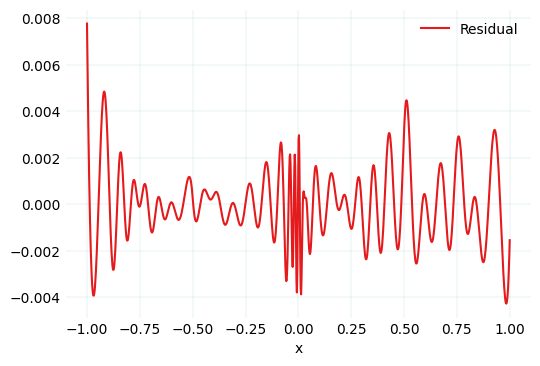

In [132]:
fig, ax = plt.subplots()
plt.plot(xlist, np.real(residual(u_ap, xlist_torch, f_rhs, e_x).detach().numpy()))
plt.xlabel("x")
plt.legend(["Residual"])

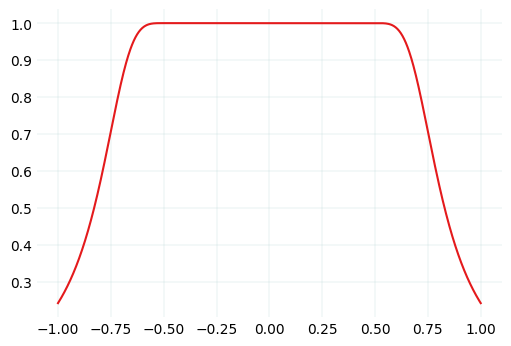

In [133]:
plt.figure()
plt.plot(xlist, np.abs(1/e_x(xlist_torch, freq=5).detach().numpy()))

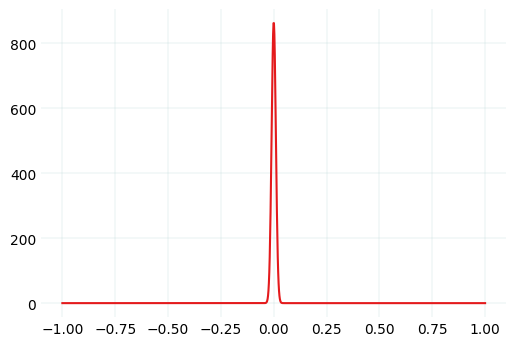

In [134]:
plt.figure()
plt.plot(xlist, np.real(f_rhs(xlist_torch).detach().numpy()))